In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [33]:
# Cargamos el dataset
df = pd.read_excel("C:/Users/brent/OneDrive/Escritorio/Streamlit_Pizzas/Data/01 Call-Center-Dataset.xlsx")
df.head()

,Call Id,Agent,Date,Time,Topic,Answered (Y/N),Resolved,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating
0,ID0001,Diane,2021-01-01,09:12:58,Contract related,Y,Y,109.0,00:02:23,3.0
1,ID0002,Becky,2021-01-01,09:12:58,Technical Support,Y,N,70.0,00:04:02,3.0
2,ID0003,Stewart,2021-01-01,09:47:31,Contract related,Y,Y,10.0,00:02:11,3.0
3,ID0004,Greg,2021-01-01,09:47:31,Contract related,Y,Y,53.0,00:00:37,2.0
4,ID0005,Becky,2021-01-01,10:00:29,Payment related,Y,Y,95.0,00:01:00,3.0


In [13]:
df.describe()

,Speed of answer in seconds,Satisfaction rating
count,4054.000000,4054.000000
mean,67.520720,3.403552
std,33.592872,1.212220
min,10.000000,1.000000
25%,39.000000,3.000000
50%,68.000000,3.000000
75%,97.000000,4.000000
max,125.000000,5.000000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Call Id                     5000 non-null   object 
 1   Agent                       5000 non-null   object 
 2   Date                        5000 non-null   object 
 3   Time                        5000 non-null   object 
 4   Topic                       5000 non-null   object 
 5   Answered (Y/N)              5000 non-null   object 
 6   Resolved                    5000 non-null   object 
 7   Speed of answer in seconds  4054 non-null   float64
 8   AvgTalkDuration             4054 non-null   object 
 9   Satisfaction rating         4054 non-null   float64
dtypes: float64(2), object(8)
memory usage: 390.8+ KB


In [15]:
df["Speed of answer in seconds"] = df["Speed of answer in seconds"].fillna(0)
df["AvgTalkDuration"] = df["AvgTalkDuration"].fillna(0)
df["Satisfaction rating"] = df["Satisfaction rating"].fillna(0)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Call Id                     5000 non-null   object 
 1   Agent                       5000 non-null   object 
 2   Date                        5000 non-null   object 
 3   Time                        5000 non-null   object 
 4   Topic                       5000 non-null   object 
 5   Answered (Y/N)              5000 non-null   object 
 6   Resolved                    5000 non-null   object 
 7   Speed of answer in seconds  5000 non-null   float64
 8   AvgTalkDuration             5000 non-null   object 
 9   Satisfaction rating         5000 non-null   float64
dtypes: float64(2), object(8)
memory usage: 390.8+ KB


In [29]:
# Total Llamadas
total_llamadas = df["Call Id"].count()
total_llamadas

5000

In [33]:
# Cantidad de agentes
Q_agentes = df["Agent"].nunique()
Q_agentes

8

In [37]:
# Porcentaje de resueltas

# Cantidad de casos resueltos
resueltas = (df["Resolved"] == "Y").sum()

# Porcentaje de resueltas
pct_resueltas = (resueltas / total_llamadas) * 100
pct_resueltas

72.92

In [47]:
# Resueltas por segundo
R_porSegundo = df["Speed of answer in seconds"].mean
R_porSegundo

<bound method Series.mean of 0       109.0
1        70.0
2        10.0
3        53.0
4        95.0
        ...  
4995     22.0
4996    100.0
4997     84.0
4998     98.0
4999      0.0
Name: Speed of answer in seconds, Length: 5000, dtype: float64>

In [49]:
# Promedio de segundos solo en los resueltos
R_porSegundo_resueltas = df.loc[df["Resolved"] == "Y", "Speed of answer in seconds"].mean()
R_porSegundo_resueltas

67.5990126165661

In [53]:
# Satisfacción
satisfaccion = df.loc[df["Resolved"] == "Y", "Satisfaction rating"].mean()
satisfaccion

3.4007131102578168

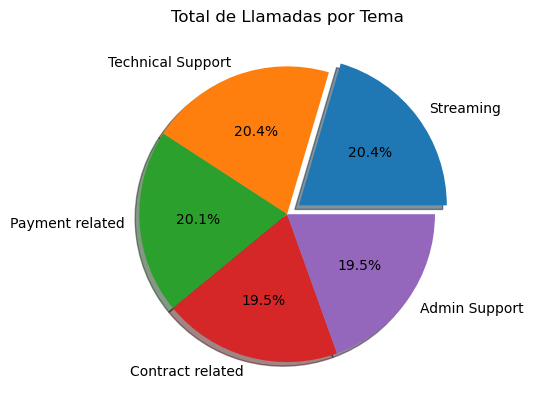

In [27]:
# Agrupar por tema y contar cuántas llamadas hay por cada uno
calls_por_topic = df['Topic'].value_counts()

# Luego graficar
plt.pie(calls_por_topic.values,
        labels=calls_per_topic.index,
        autopct='%1.1f%%',
        shadow=True,
        explode=[0.1 if i == calls_por_topic.idxmax() else 0 for i in calls_por_topic.index])
plt.title("Total de Llamadas por Tema")
plt.show()

In [31]:
#Convertí la columna Date a tipo fecha y agregá el día de la semana
df['Date'] = pd.to_datetime(df['Date'])
df['DayOfWeek'] = df['Date'].dt.day_name()  # Ej: Monday, Tuesday...

#Calculá la cantidad de llamadas resueltas y atendidas por día
# Agrupar por día y contar según las columnas 'Resolved' y 'Answered (Y/N)'
summary = df.groupby('DayOfWeek').agg({
    'Resolved': lambda x: (x == 'Y').sum(),
    'Answered (Y/N)': lambda x: (x == 'Y').sum()
}).reset_index()

# Renombrar columnas para claridad
summary.columns = ['Día de la semana', 'Resueltas', 'Atendidas']

# Mostrar la tabla ordenada por día (opcional)
# Ordenar los días en el orden correcto
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
summary['Día de la semana'] = pd.Categorical(summary['Día de la semana'], categories=order, ordered=True)
summary = summary.sort_values('Día de la semana')

print(summary.to_string(index=False))

Día de la semana  Resueltas  Atendidas
          Monday        571        629
         Tuesday        502        554
       Wednesday        489        544
        Thursday        533        579
          Friday        476        546
        Saturday        542        614
          Sunday        533        588


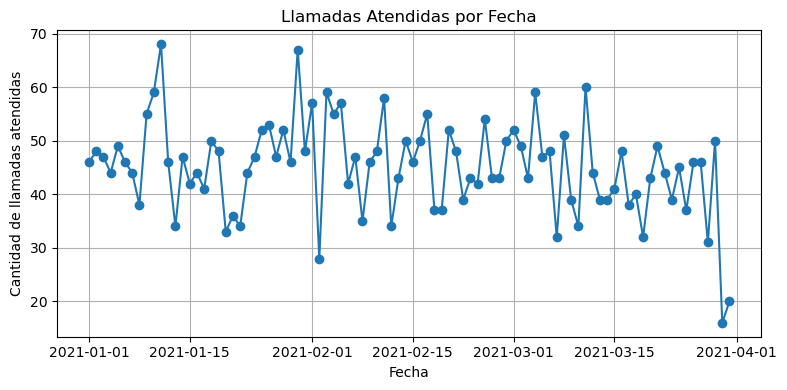

In [33]:
# Aseguramos tipo fecha
df['Date'] = pd.to_datetime(df['Date'])

# Filtrar solo las llamadas atendidas
attended = df[df['Answered (Y/N)'] == 'Y']

# Agrupar por fecha
attended_per_day = attended.groupby('Date').size()

# Gráfico de líneas
plt.figure(figsize=(8, 4))
plt.plot(attended_per_day.index, attended_per_day.values, marker='o')
plt.title("Llamadas Atendidas por Fecha")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de llamadas atendidas")
plt.grid(True)
plt.tight_layout()
plt.show()


In [21]:
# Sector Agentes
# Llamadas atendidas - resueltas por agentes

# Normalizar columnas clave
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Answered'] = df['Answered (Y/N)'].fillna('N').astype(str)
df['Resolved'] = df['Resolved'].fillna('N').astype(str)
df['Speed of answer in seconds'] = pd.to_numeric(df['Speed of answer in seconds'], errors='coerce').fillna(0)
df['Satisfaction rating'] = pd.to_numeric(df['Satisfaction rating'], errors='coerce').fillna(0)

# ---------- SECTOR AGENTES ----------
# Tabla: Agentes - Total llamadas - resueltas - no resueltas
agent_tbl = df.groupby('Agent').agg(
    Total_Llamadas = ('Call Id', 'count'),
    Atendidas = ('Answered', lambda x: (x == 'Y').sum()),
    Resueltas = ('Resolved', lambda x: (x == 'Y').sum())
).reset_index()
agent_tbl['No_Resueltas'] = agent_tbl['Atendidas'] - agent_tbl['Resueltas']
print("Tabla por agente:\n", agent_tbl.sort_values('Total_Llamadas', ascending=False), "\n")

Tabla por agente:
      Agent  Total_Llamadas  Atendidas  Resueltas  No_Resueltas
4      Jim             666        536        485            51
6   Martha             638        514        461            53
1      Dan             633        523        471            52
2    Diane             633        501        452            49
0    Becky             631        517        462            55
3     Greg             624        502        455            47
5      Joe             593        484        436            48
7  Stewart             582        477        424            53 



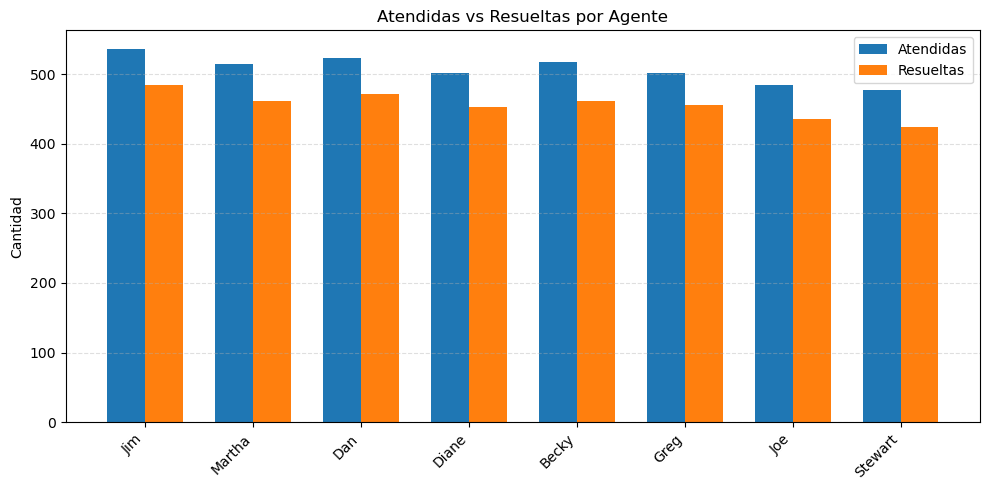

In [23]:
# Tendencia llamadas resueltas
# Gráfico 1: Llamadas atendidas vs resueltas por agente (barras agrupadas)
agent_tbl_sorted = agent_tbl.sort_values('Total_Llamadas', ascending=False)
x = range(len(agent_tbl_sorted))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], agent_tbl_sorted['Atendidas'], width=width, label='Atendidas')
ax.bar([i + width/2 for i in x], agent_tbl_sorted['Resueltas'], width=width, label='Resueltas')
ax.set_xticks(x)
ax.set_xticklabels(agent_tbl_sorted['Agent'], rotation=45, ha='right')
ax.set_ylabel('Cantidad')
ax.set_title('Atendidas vs Resueltas por Agente')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

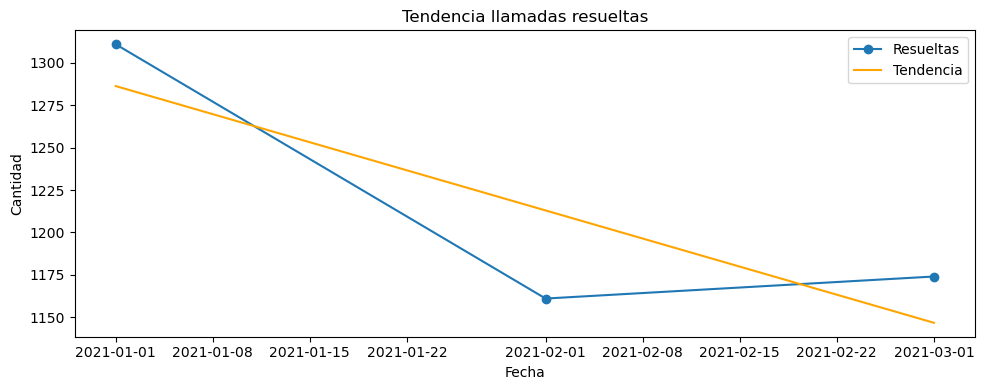

In [39]:
# Tabla con las columnas Agentes - Total llamadas - resueltas y no resueltas
# Gráfico 2: Tendencia de llamadas resueltas (serie temporal)
# Asegurar que 'Date' sea tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# Agrupar llamadas resueltas por fecha
resolved_ts = df[df['Resolved'] == 'Y'].groupby('Date').size().sort_index()

# Convertir índice a DatetimeIndex (necesario para resample)
resolved_ts.index = pd.to_datetime(resolved_ts.index)

# Reagrupar por mes
resolved_monthly = resolved_ts.resample('MS').sum()

# Línea de tendencia (regresión lineal)
x = mdates.date2num(resolved_monthly.index.to_pydatetime())
y = resolved_monthly.values
coef = np.polyfit(x, y, 1)
trend = np.polyval(coef, x)

# Gráfico
plt.figure(figsize=(10, 4))
plt.plot(resolved_monthly.index, resolved_monthly.values, marker='o', label='Resueltas')
plt.plot(resolved_monthly.index, trend, color='orange', label='Tendencia')
plt.title('Tendencia llamadas resueltas')
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.legend()
plt.tight_layout()
plt.show()

Promedio satisfacción por tema:
                Topic  Avg_Satisfaction
3          Streaming          2.819961
0      Admin Support          2.790984
2    Payment related          2.758689
1   Contract related          2.730533
4  Technical Support          2.697743 



C:\Users\brent\AppData\Local\Temp\ipykernel_5252\958135764.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(satisfaction_by_topic['Topic'], rotation=45, ha='right')


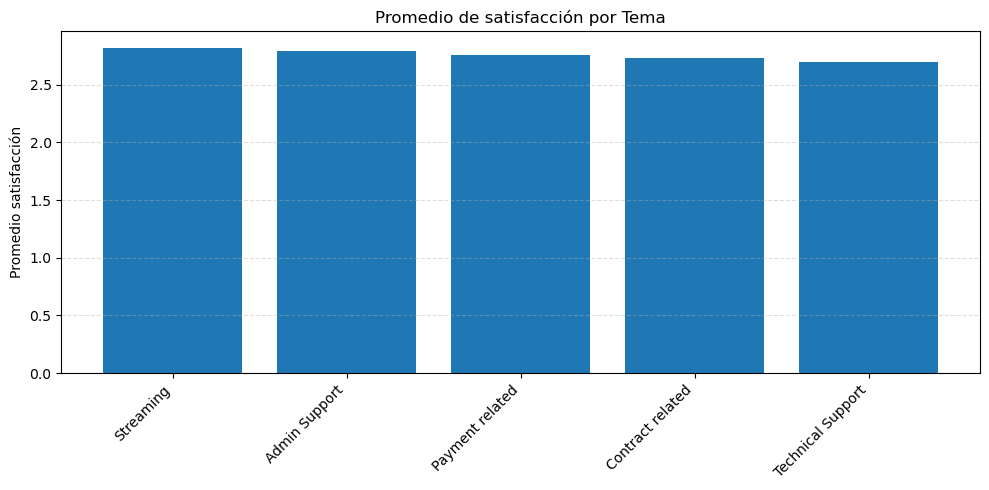

In [15]:
# ---------- SECTOR TEMAS ----------
# Promedio satisfacción por tema
satisfaction_by_topic = df.groupby('Topic')['Satisfaction rating'].mean().reset_index().rename(columns={'Satisfaction rating':'Avg_Satisfaction'})
satisfaction_by_topic = satisfaction_by_topic.sort_values('Avg_Satisfaction', ascending=False)
print("Promedio satisfacción por tema:\n", satisfaction_by_topic, "\n")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(satisfaction_by_topic['Topic'], satisfaction_by_topic['Avg_Satisfaction'])
ax.set_xticklabels(satisfaction_by_topic['Topic'], rotation=45, ha='right')
ax.set_ylabel('Promedio satisfacción')
ax.set_title('Promedio de satisfacción por Tema')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Llamadas no atendidas por tema:
                Topic  No_Atendidas
4  Technical Support           214
2    Payment related           189
1   Contract related           187
0      Admin Support           181
3          Streaming           175 



C:\Users\brent\AppData\Local\Temp\ipykernel_5252\1953612944.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(not_answered_by_topic['Topic'], rotation=45, ha='right')


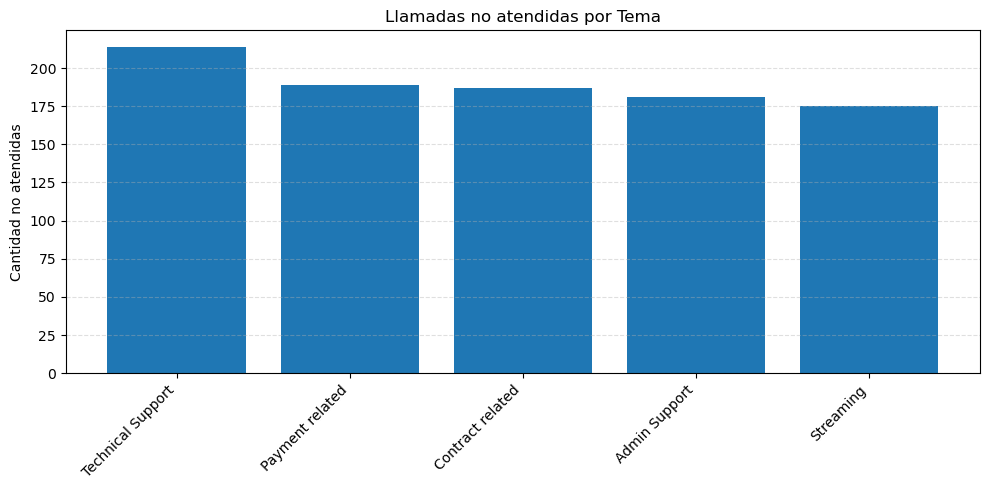

In [13]:
# Llamadas no atendidas por tema
# Llamadas no atendidas por tema
not_answered_by_topic = df[df['Answered'] != 'Y'].groupby('Topic').size().reset_index(name='No_Atendidas').sort_values('No_Atendidas', ascending=False)
print("Llamadas no atendidas por tema:\n", not_answered_by_topic, "\n")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(not_answered_by_topic['Topic'], not_answered_by_topic['No_Atendidas'])
ax.set_xticklabels(not_answered_by_topic['Topic'], rotation=45, ha='right')
ax.set_ylabel('Cantidad no atendidas')
ax.set_title('Llamadas no atendidas por Tema')
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
# Tabla con los temas y el porcentaje de resueltas y no resueltas
# Tabla: temas y porcentaje de resueltas / no resueltas
topic_counts = df.groupby('Topic').agg(
    Total = ('Call Id', 'count'),
    Resueltas = ('Resolved', lambda x: (x == 'Y').sum())
).reset_index()
topic_counts['No_Resueltas'] = topic_counts['Total'] - topic_counts['Resueltas']
topic_counts['Pct_Resueltas'] = (topic_counts['Resueltas'] / topic_counts['Total'] * 100).round(2)
topic_counts['Pct_No_Resueltas'] = (topic_counts['No_Resueltas'] / topic_counts['Total'] * 100).round(2)
print("Tabla por tema (totales y % resueltas/no resueltas):\n", topic_counts.sort_values('Total', ascending=False), "\n")

Tabla por tema (totales y % resueltas/no resueltas):
                Topic  Total  Resueltas  No_Resueltas  Pct_Resueltas  \
3          Streaming   1022        749           273          73.29   
4  Technical Support   1019        736           283          72.23   
2    Payment related   1007        729           278          72.39   
0      Admin Support    976        723           253          74.08   
1   Contract related    976        709           267          72.64   

   Pct_No_Resueltas  
3             26.71  
4             27.77  
2             27.61  
0             25.92  
1             27.36   



In [9]:
# Tabla con los temas Indice de satisfaccion y la velocidad de respusta en segundos
# Tabla: temas con índice de satisfacción y velocidad de respuesta (promedios)
topic_kpis = df.groupby('Topic').agg(
    Avg_Satisfaction = ('Satisfaction rating', 'mean'),
    Avg_Speed_seconds = ('Speed of answer in seconds', 'mean'),
    Count = ('Call Id', 'count')
).reset_index().sort_values('Count', ascending=False)
topic_kpis['Avg_Satisfaction'] = topic_kpis['Avg_Satisfaction'].round(2)
topic_kpis['Avg_Speed_seconds'] = topic_kpis['Avg_Speed_seconds'].round(1)
print("KPIs por tema (satisfacción y velocidad de respuesta):\n", topic_kpis, "\n")

KPIs por tema (satisfacción y velocidad de respuesta):
                Topic  Avg_Satisfaction  Avg_Speed_seconds  Count
3          Streaming              2.82               55.4   1022
4  Technical Support              2.70               53.8   1019
2    Payment related              2.76               55.4   1007
0      Admin Support              2.79               54.8    976
1   Contract related              2.73               54.3    976 

